In [81]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [82]:
df = pd.read_csv('train.csv')

#define financial features sub-dataframe

financial = df[['budget', 'revenue']].copy()

print(financial.describe())

print(f'\n Isna Entries: \n{financial.isna().sum()}') # count all isnas

print(f'\n Zero Entries: \n{(financial == 0).sum()}') # count all zero's


             budget       revenue
count  3.000000e+03  3.000000e+03
mean   2.253133e+07  6.672585e+07
std    3.702609e+07  1.375323e+08
min    0.000000e+00  1.000000e+00
25%    0.000000e+00  2.379808e+06
50%    8.000000e+06  1.680707e+07
75%    2.900000e+07  6.891920e+07
max    3.800000e+08  1.519558e+09

 Isna Entries: 
budget     0
revenue    0
dtype: int64

 Zero Entries: 
budget     812
revenue      0
dtype: int64


In [83]:
# Replace 0 budget entries with nans and drop corresponding rows

financial = financial.replace(0, np.nan).dropna()

Text(0.5, 1.0, 'Distribution of Log Revenue')

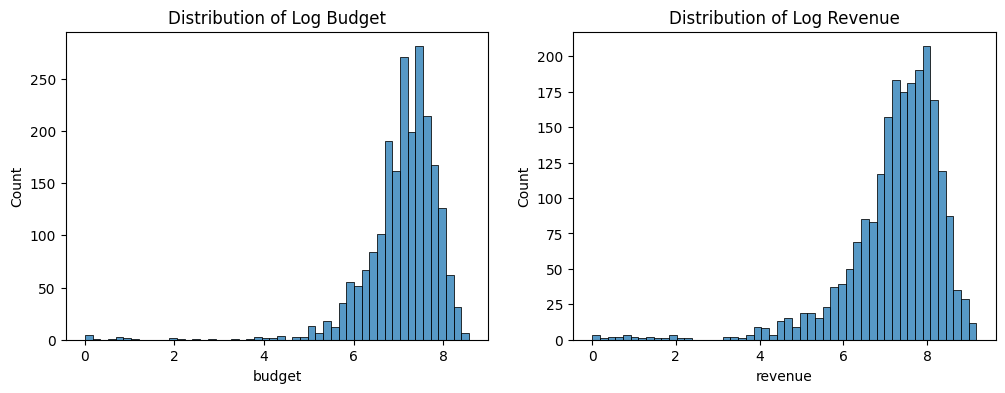

In [84]:
# Investigating the distributions 

fig, axes = plt.subplots(1, 2, figsize = (12,4))

sns.histplot(
    np.log10(financial['budget']),
    bins = 50,
    ax = axes[0]
)

axes[0].set_title('Distribution of Log Budget')

sns.histplot(
    np.log10(financial['revenue']),
    bins = 50,
    ax = axes[1]
)

axes[1].set_title('Distribution of Log Revenue')



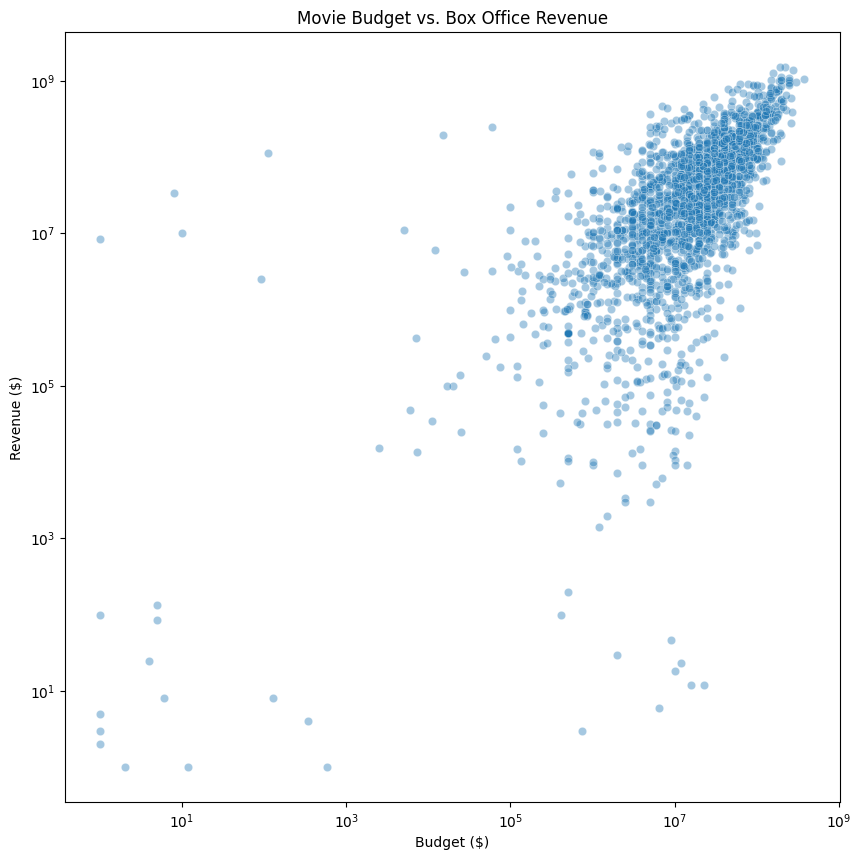

In [85]:
# Scatterplot of budget vs. revenue
plt.figure(figsize = (10, 10))

sns.scatterplot(
    data = financial,
    x = 'budget', 
    y = 'revenue',
    alpha = 0.4
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.title('Movie Budget vs. Box Office Revenue')

plt.show()


In [91]:
# Clustering

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

features = [
    'budget',
    'revenue',
    'runtime',
    'popularity',
]

data = df[features].copy()

for col in features:
    data[col] = pd.to_numeric(data[col], errors = 'coerce')

data.head(5)

data = data[
    (data['budget'] > 0) & 
    (data['revenue'] > 0) & 
    (data['runtime'] > 0) & 
    (data['popularity'] >= 0) 
    ].dropna().copy()

data.head(5)

data['log_budget'] = np.log10(data['budget'])
data['log_revenue'] = np.log10(data['revenue'])
data['log_popularity'] = np.log10(data['popularity'])

data['log_multiple'] = (
    data['log_revenue'] - data['log_budget']
)

cluster_features = [
   f'log_{str(i)}' for i in features if i != 'runtime']
cluster_features += ['log_multiple', 'runtime']

X = data[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_list = [KMeans(
    n_clusters = i,
    random_state = 40,
    n_init = 20
) for i in range(3, 7)]


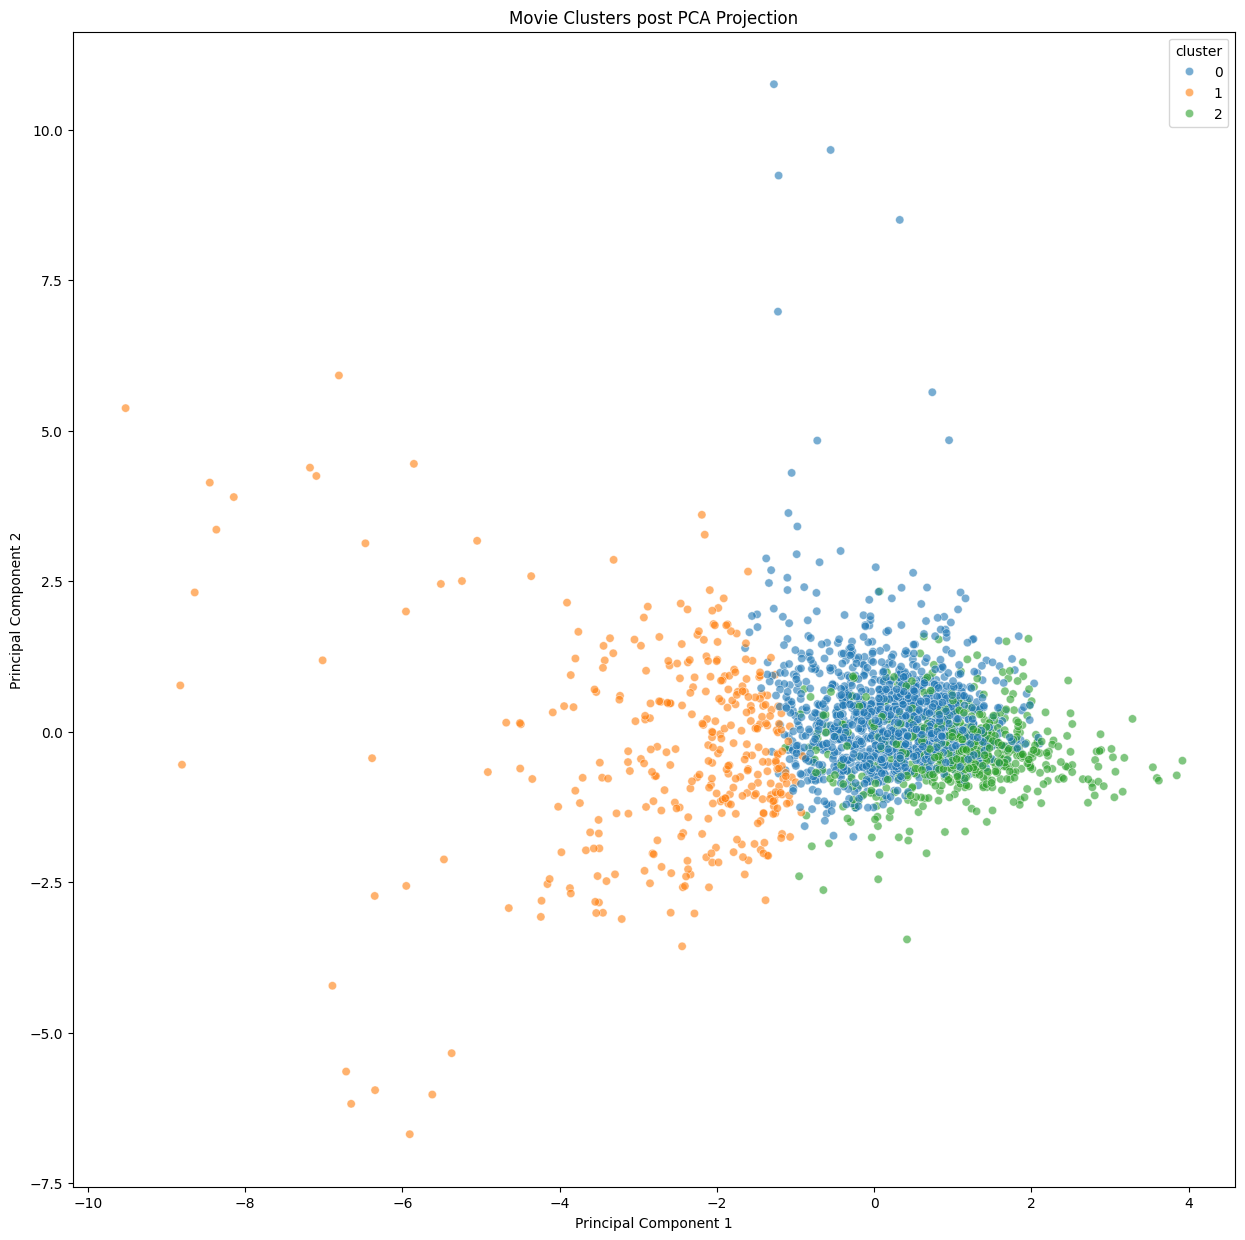

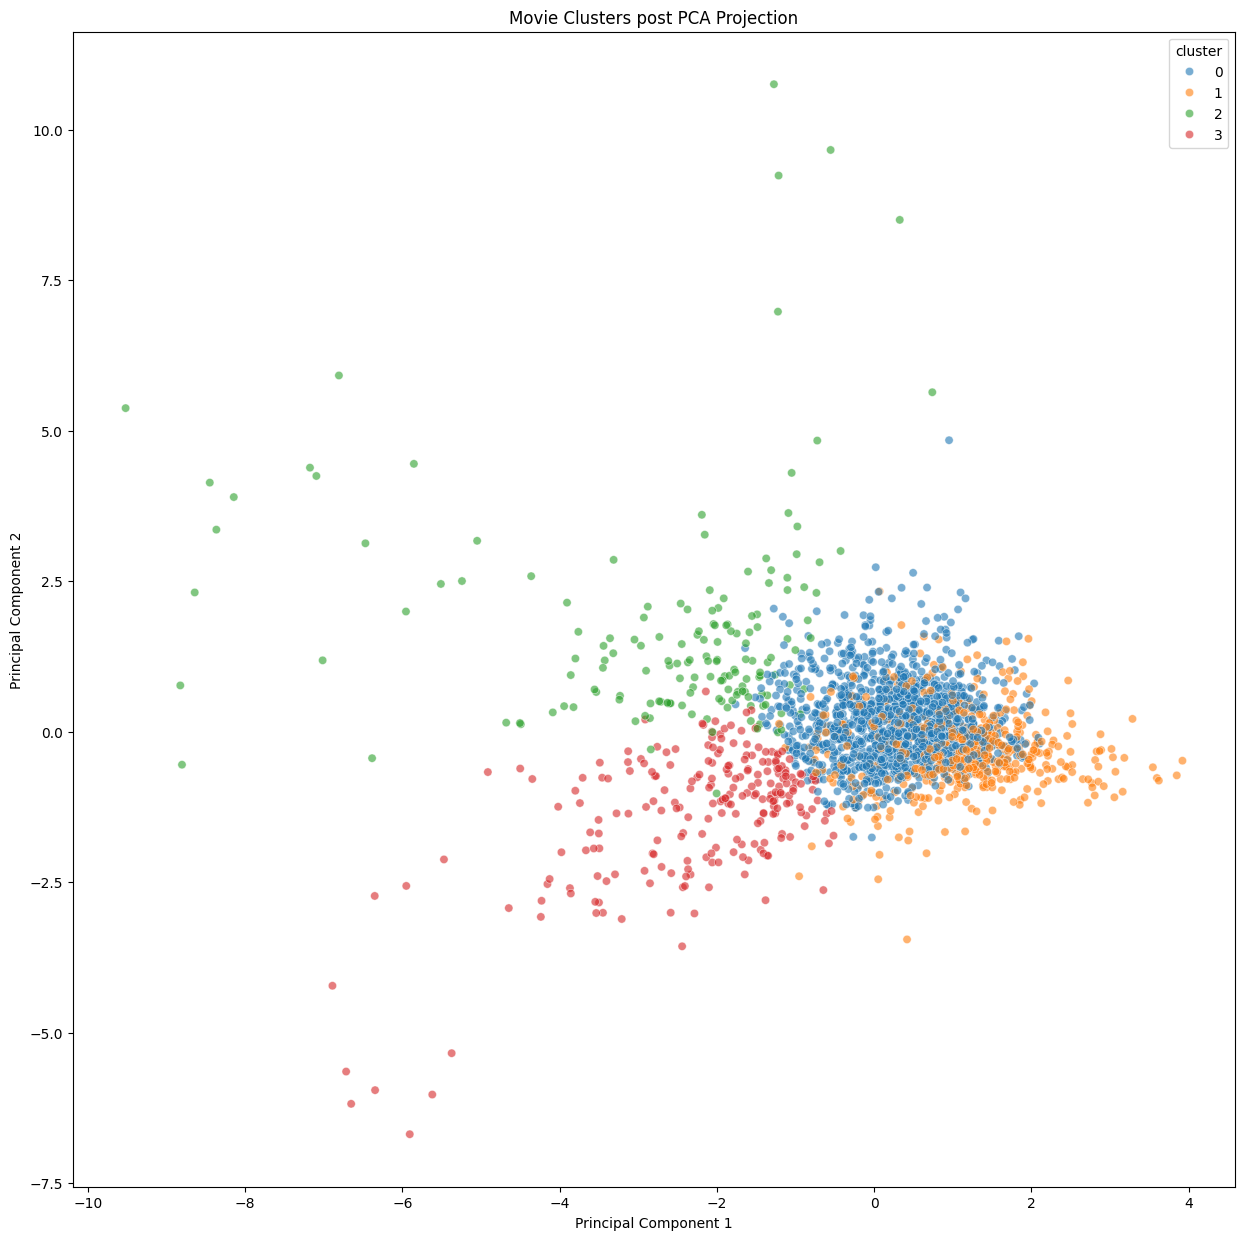

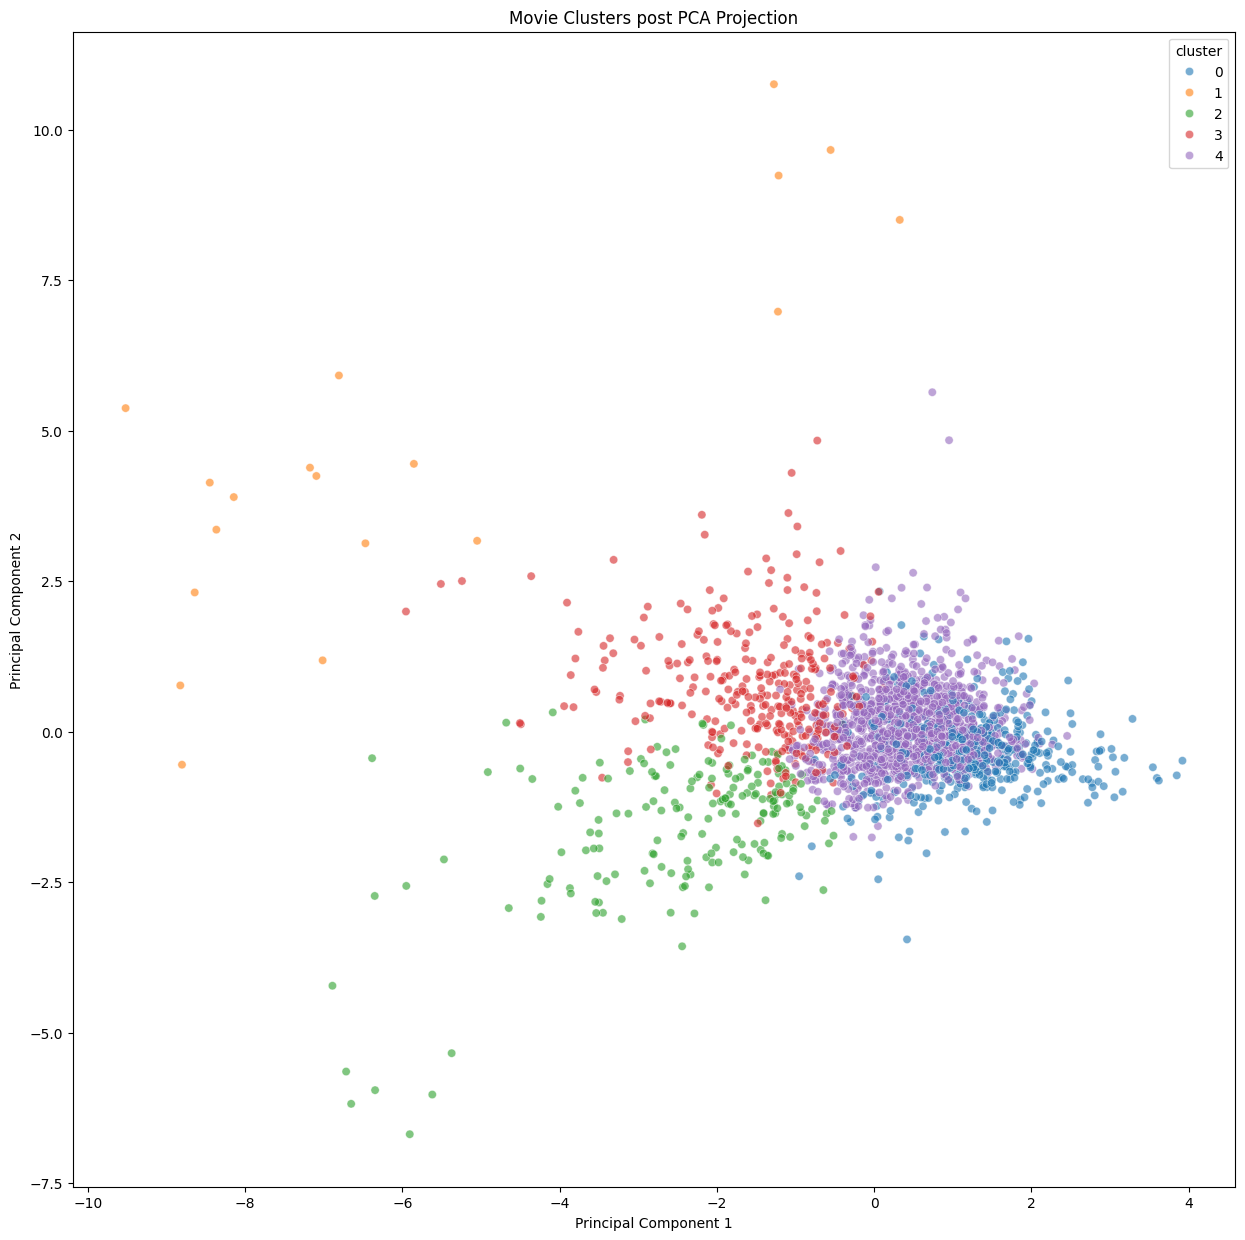

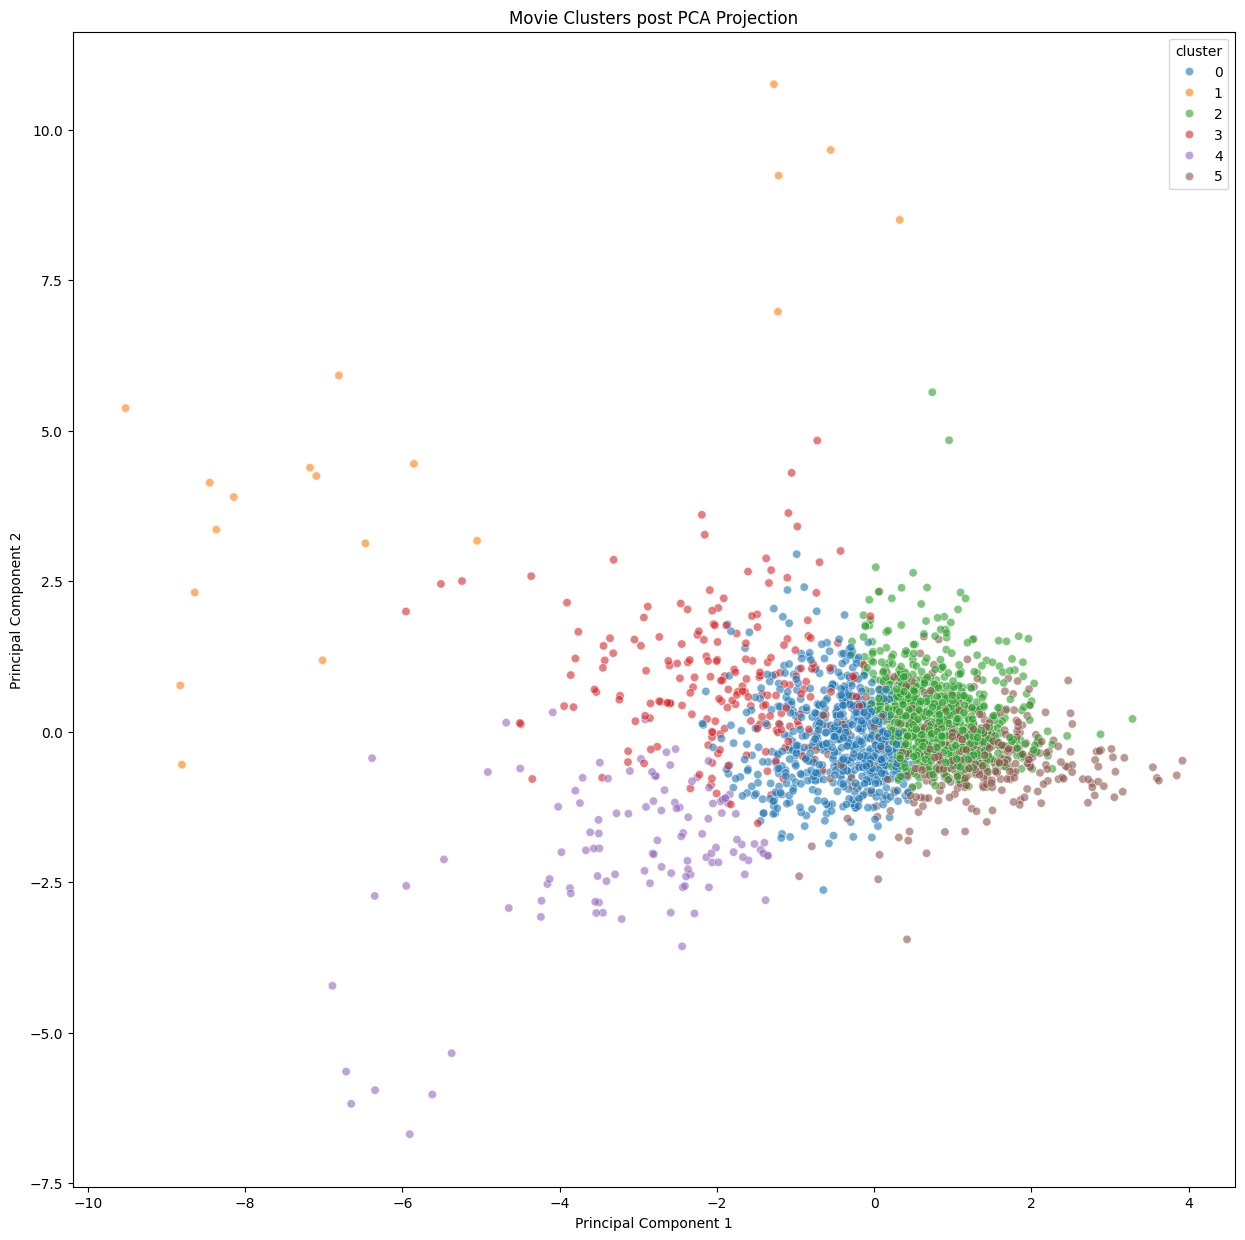

Explained Variance: [0.45898577 0.23597057]


In [93]:
# PCA for visualization

def PCA_cluster_test(kmeans):
    data['cluster'] = kmeans.fit_predict(X_scaled)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize = (15, 15))
    
    sns.scatterplot(
        x = X_pca[:, 0],
        y = X_pca[:, 1],
        hue = data['cluster'],
        palette = 'tab10',
        alpha = 0.6
    )
    
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('Movie Clusters post PCA Projection')
    
    plt.show()
    

for i in kmeans_list:
    PCA_cluster_test(i)
print(f'Explained Variance: { pca.explained_variance_ratio_}')
